# Correlation Analysis: Steam games genrs to 2019

## 1. Purpose of the Project
## This project is conducted with two primary goals:
- *Learning & Skill Growth:* To practice advanced data manipulation techniques using Pandas and Numpy, focusing on real-world dataset reshaping and statictical analysis.
- *Game Development Insight:* To analyze genre correlation for game currently in development.

**"Feedback and suggestions are always welcome as I continue to learn and refine this project."**


## 2. Future Rodmab(2026/03/09)
- [x] **Data Visuallization:** Visualize genre correlations using a Heatmap
- [ ] **Precise Analysis**: Incorporate **'Category'** data alongside genres for more granular insights.

In [10]:
#해당 파일의 디렉토리 경로

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt

pd.options.display.float_format = '{:.2f}'.format

import os
for dirname, _, filenames in os.walk('/kaggle/input/'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/nikdavis/steam-store-games/steam_support_info.csv
/kaggle/input/datasets/nikdavis/steam-store-games/steam_media_data.csv
/kaggle/input/datasets/nikdavis/steam-store-games/steamspy_tag_data.csv
/kaggle/input/datasets/nikdavis/steam-store-games/steam_requirements_data.csv
/kaggle/input/datasets/nikdavis/steam-store-games/steam_description_data.csv
/kaggle/input/datasets/nikdavis/steam-store-games/steam.csv


In [11]:
steam_raw = pd.read_csv("/kaggle/input/datasets/nikdavis/steam-store-games/steam.csv") # 해당 경로의 CSV 파일을 읽어와서 Pandas의 'DataFrame' 객체로 변환하여 steam_raw 변수에 저장

steam_raw.head()

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
0,10,Counter-Strike,2000-11-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,124534,3339,17612,317,10000000-20000000,7.19
1,20,Team Fortress Classic,1999-04-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,3318,633,277,62,5000000-10000000,3.99
2,30,Day of Defeat,2003-05-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Valve Anti-Cheat enabled,Action,FPS;World War II;Multiplayer,0,3416,398,187,34,5000000-10000000,3.99
3,40,Deathmatch Classic,2001-06-01,1,Valve,Valve,windows;mac;linux,0,Multi-player;Online Multi-Player;Local Multi-P...,Action,Action;FPS;Multiplayer,0,1273,267,258,184,5000000-10000000,3.99
4,50,Half-Life: Opposing Force,1999-11-01,1,Gearbox Software,Valve,windows;mac;linux,0,Single-player;Multi-player;Valve Anti-Cheat en...,Action,FPS;Action;Sci-fi,0,5250,288,624,415,5000000-10000000,3.99


In [12]:
#각 column의 정보
steam_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             27075 non-null  int64  
 1   name              27075 non-null  object 
 2   release_date      27075 non-null  object 
 3   english           27075 non-null  int64  
 4   developer         27074 non-null  object 
 5   publisher         27061 non-null  object 
 6   platforms         27075 non-null  object 
 7   required_age      27075 non-null  int64  
 8   categories        27075 non-null  object 
 9   genres            27075 non-null  object 
 10  steamspy_tags     27075 non-null  object 
 11  achievements      27075 non-null  int64  
 12  positive_ratings  27075 non-null  int64  
 13  negative_ratings  27075 non-null  int64  
 14  average_playtime  27075 non-null  int64  
 15  median_playtime   27075 non-null  int64  
 16  owners            27075 non-null  object

In [13]:
steam_raw.describe(include="all")

#count: 데이터의 개수
#unique: 고윳값의 수(중복 제외 데이터 수)
#top: 가장 많이 등장하는 value
#freq: 전체 데이터에서 top에 나온 value의 개수
#mean: 평균값
#std: 표준편차
#min: 최솟값
#25%: 하위 25% 지점
#%50: 중앙값
#75%: 상위 25% 지점
#max: 최대값

,appid,name,release_date,english,developer,publisher,platforms,required_age,categories,genres,steamspy_tags,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,owners,price
count,27075.00,27075,27075,27075.00,27074,27061,27075,27075.00,27075,27075,27075,27075.00,27075.00,27075.00,27075.00,27075.00,27075,27075.00
unique,NaN,27033,2619,NaN,17112,14353,7,NaN,3333,1552,6423,NaN,NaN,NaN,NaN,NaN,13,NaN
top,NaN,Dark Matter,2018-07-13,NaN,Choice of Games,Big Fish Games,windows,NaN,Single-player,Action;Indie,Action;Indie;Casual,NaN,NaN,NaN,NaN,NaN,0-20000,NaN
freq,NaN,3,64,NaN,94,212,18398,NaN,6110,1852,845,NaN,NaN,NaN,NaN,NaN,18596,NaN
mean,596203.51,NaN,NaN,0.98,NaN,NaN,NaN,0.35,NaN,NaN,NaN,45.25,1000.56,211.03,149.80,146.06,NaN,6.08
std,250894.17,NaN,NaN,0.14,NaN,NaN,NaN,2.41,NaN,NaN,NaN,352.67,18988.72,4284.94,1827.04,2353.88,NaN,7.87
min,10.00,NaN,NaN,0.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,0.00,0.00,0.00,0.00,NaN,0.00
25%,401230.00,NaN,NaN,1.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,0.00,6.00,2.00,0.00,0.00,NaN,1.69
50%,599070.00,NaN,NaN,1.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,7.00,24.00,9.00,0.00,0.00,NaN,3.99
75%,798760.00,NaN,NaN,1.00,NaN,NaN,NaN,0.00,NaN,NaN,NaN,23.00,126.00,42.00,0.00,0.00,NaN,7.19


In [14]:
# 장르에 따른 추천 시스템을 구현 하기 위한 필요한 컬럼만 추출
steam_mini = steam_raw[['appid', 'name', 'genres', 'categories']].copy()

# 결측치(비어있는 값)가 있으면 그 행을 제거
# 지금은 결측값 데이터가 그리 많지 않으므로 삭제 하지만 추후에 api로 데이터를 끌고 올때는 없는 값에 대한건 따로 저장 한 후 수동으로 설정하는 방식 생각중)
steam_mini = steam_mini.dropna()

# 기존의 index를 appid로 교체(추후 appid를 통해 탐색 용이)
steam_mini = steam_mini.set_index('appid')

# 세미콜론(;) 쪼개기 (리스트 형태로 변환)
steam_mini['genre_list'] = steam_mini['genres'].str.split(';')
steam_mini['category_list'] = steam_mini['categories'].str.split(';')

# 혹시 모를 중복값 제거
steam_mini['genre_list'] = steam_mini['genre_list'].apply(lambda x: list(set(x)))
steam_mini['category_list'] = steam_mini['category_list'].apply(lambda x: list(set(x)))

# 결과 확인
steam_mini.head()

,name,genres,categories,genre_list,category_list
appid,,,,,
10,Counter-Strike,Action,Multi-player;Online Multi-Player;Local Multi-P...,[Action],"[Online Multi-Player, Multi-player, Local Mult..."
20,Team Fortress Classic,Action,Multi-player;Online Multi-Player;Local Multi-P...,[Action],"[Online Multi-Player, Multi-player, Local Mult..."
30,Day of Defeat,Action,Multi-player;Valve Anti-Cheat enabled,[Action],"[Multi-player, Valve Anti-Cheat enabled]"
40,Deathmatch Classic,Action,Multi-player;Online Multi-Player;Local Multi-P...,[Action],"[Online Multi-Player, Multi-player, Local Mult..."
50,Half-Life: Opposing Force,Action,Single-player;Multi-player;Valve Anti-Cheat en...,[Action],"[Single-player, Multi-player, Valve Anti-Cheat..."


In [15]:
#appid 값을 제거한 나머지 통계값
steam_mini.describe(include="object")

,name,genres,categories,genre_list,category_list
count,27075,27075,27075,27075,27075
unique,27033,1552,3333,1539,3333
top,Dark Matter,Action;Indie,Single-player,"[Action, Indie]",[Single-player]
freq,3,1852,6110,1852,6110


In [16]:
# 리스트로 된 장르 데이터를 개별 행으로 펼치기 (Explode)
# 한 행에 ['Action', 'Indie']가 들어있다면 두 개의 행으로 복사됨
# ex) appid | name | genres
#      10      A     Action
#      10      A     Indie


genres_exploded = steam_mini.explode('genre_list')

genres_exploded

,name,genres,categories,genre_list,category_list
appid,,,,,
10,Counter-Strike,Action,Multi-player;Online Multi-Player;Local Multi-P...,Action,"[Online Multi-Player, Multi-player, Local Mult..."
20,Team Fortress Classic,Action,Multi-player;Online Multi-Player;Local Multi-P...,Action,"[Online Multi-Player, Multi-player, Local Mult..."
30,Day of Defeat,Action,Multi-player;Valve Anti-Cheat enabled,Action,"[Multi-player, Valve Anti-Cheat enabled]"
40,Deathmatch Classic,Action,Multi-player;Online Multi-Player;Local Multi-P...,Action,"[Online Multi-Player, Multi-player, Local Mult..."
50,Half-Life: Opposing Force,Action,Single-player;Multi-player;Valve Anti-Cheat en...,Action,"[Single-player, Multi-player, Valve Anti-Cheat..."
...,...,...,...,...,...
1066700,New Yankee 7: Deer Hunters,Adventure;Casual;Indie,Single-player;Steam Cloud,Casual,"[Single-player, Steam Cloud]"
1066700,New Yankee 7: Deer Hunters,Adventure;Casual;Indie,Single-player;Steam Cloud,Indie,"[Single-player, Steam Cloud]"
1069460,Rune Lord,Adventure;Casual;Indie,Single-player;Steam Cloud,Adventure,"[Single-player, Steam Cloud]"


In [17]:
# 2. 원-핫 인코딩 (One-Hot Encoding)
# 각 게임(index)이 어떤 장르를 가졌는지 0과 1의 표로 변환
# groupby(level=0).sum()을 통해 explode로 늘어난 행을 다시 합쳐줌 
genre_dummies = pd.get_dummies(genres_exploded['genre_list']).groupby(level=0).sum()

genre_dummies

,Accounting,Action,Adventure,Animation & Modeling,Audio Production,Casual,Design & Illustration,Documentary,Early Access,Education,...,Sexual Content,Simulation,Software Training,Sports,Strategy,Tutorial,Utilities,Video Production,Violent,Web Publishing
appid,,,,,,,,,,,,,,,,,,,,,
10,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
20,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
30,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
40,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
50,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1065230,0,0,1,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1065570,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1065650,0,1,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [18]:
#  상관계수 계산 (Pearson Correlation)
# 장르 컬럼들끼리 얼마나 자주 같이 나타나는지 계산 (-1.0 ~ 1.0)
genre_corr = genre_dummies.corr()

# 수치 결과 확인 (상위 5개 장르 예시)
genre_corr.head()

,Accounting,Action,Adventure,Animation & Modeling,Audio Production,Casual,Design & Illustration,Documentary,Early Access,Education,...,Sexual Content,Simulation,Software Training,Sports,Strategy,Tutorial,Utilities,Video Production,Violent,Web Publishing
Accounting,1.00,-0.01,-0.01,0.14,0.23,0.01,0.17,0.41,0.00,0.23,...,-0.00,-0.00,0.37,-0.00,-0.00,0.41,0.13,0.20,-0.00,0.31
Action,-0.01,1.00,0.02,-0.05,-0.03,-0.17,-0.05,-0.01,0.10,-0.04,...,-0.04,-0.14,-0.03,-0.01,-0.15,-0.01,-0.07,-0.03,0.10,-0.03
Adventure,-0.01,0.02,1.00,-0.04,-0.03,-0.03,-0.04,-0.00,-0.02,-0.03,...,0.01,-0.10,-0.03,-0.11,-0.14,-0.00,-0.06,-0.02,0.04,-0.02
Animation & Modeling,0.14,-0.05,-0.04,1.00,0.14,-0.03,0.65,-0.00,0.03,0.39,...,-0.01,-0.02,0.42,-0.01,-0.02,-0.00,0.49,0.35,-0.01,0.32
Audio Production,0.23,-0.03,-0.03,0.14,1.00,-0.02,0.12,-0.00,0.01,0.13,...,-0.00,-0.01,0.17,-0.01,-0.01,-0.00,0.26,0.21,-0.01,0.21


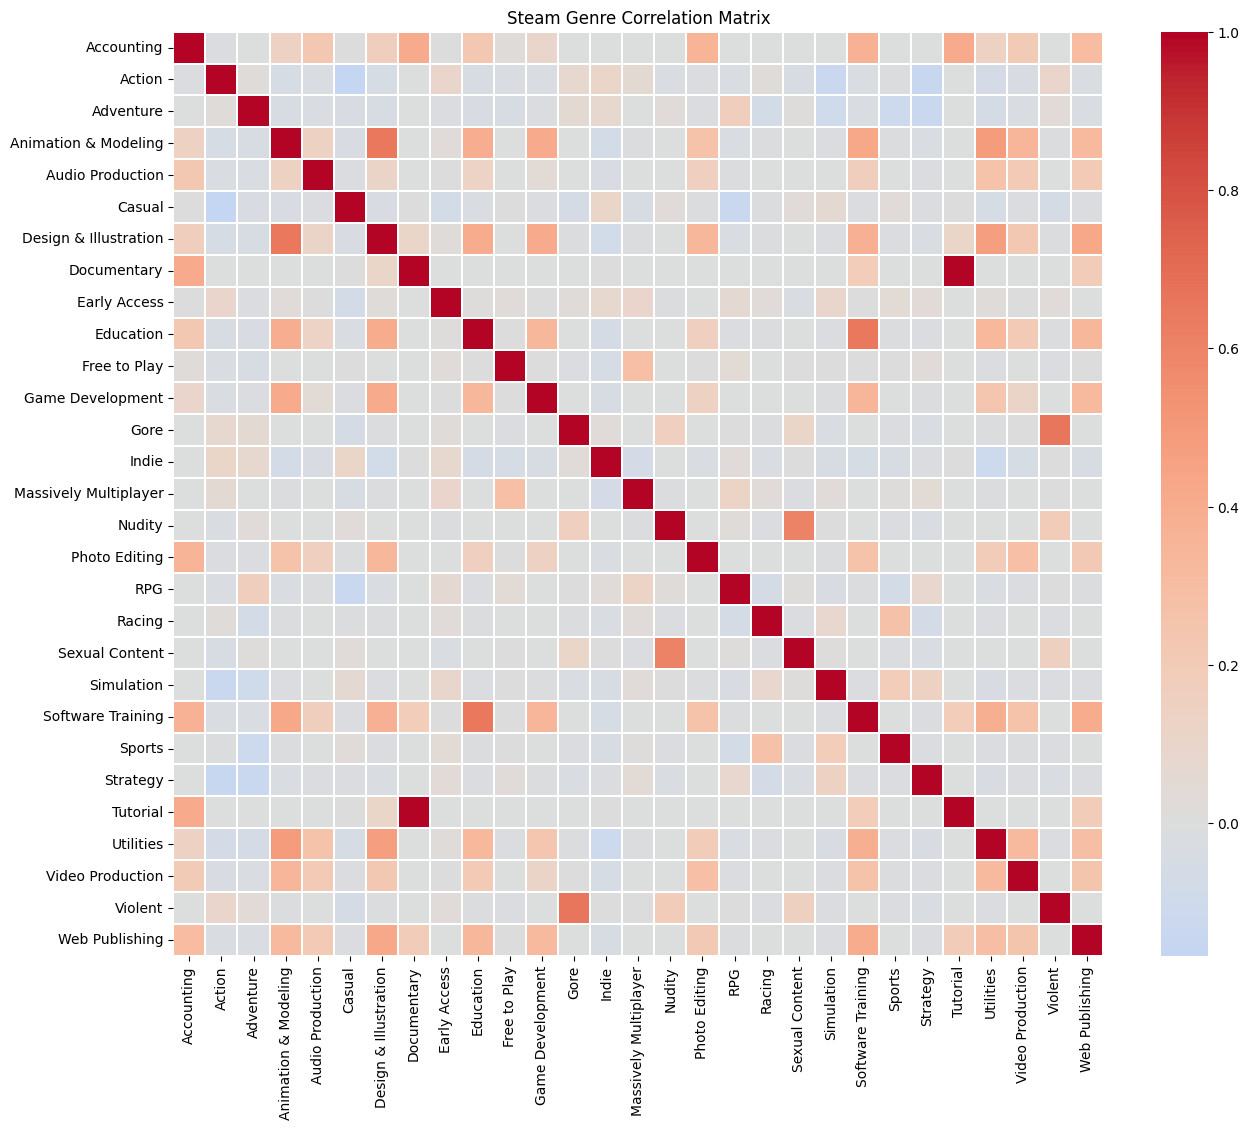

In [19]:
# 시각화 (Heatmap)
plt.figure(figsize=(15, 12))
sns.heatmap(genre_corr, 
            annot=False,      # 장르가 많으므로 숫자는 생략
            cmap='coolwarm',  # 양의 상관관계(빨강), 음의 상관관계(파랑)
            center=0,         # 0(상관없음)을 기준으로 색상 분리
            linewidths=0.05)
plt.title('Steam Genre Correlation Matrix')
plt.show()

In [20]:
# (Accounting, Action), (Action, Accounting) 같은 중복 값이 나온다.
# Why) 위에 처럼 상관관계 Matrix에는 중앙의 대각선을 기준으로 대칭이기 때문
# 추후 mask() 를 사용 하기위해 상삼각형을 구해 그 값을 True로 채움

mask = np.triu(np.ones_like(genre_corr, dtype=bool))
pd.DataFrame(mask).head(10)

,0,1,2,3,4,5,6,7,8,9,...,19,20,21,22,23,24,25,26,27,28
0,True,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
1,False,True,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
2,False,False,True,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
3,False,False,False,True,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
4,False,False,False,False,True,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
5,False,False,False,False,False,True,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
6,False,False,False,False,False,False,True,True,True,True,...,True,True,True,True,True,True,True,True,True,True
7,False,False,False,False,False,False,False,True,True,True,...,True,True,True,True,True,True,True,True,True,True
8,False,False,False,False,False,False,False,False,True,True,...,True,True,True,True,True,True,True,True,True,True
9,False,False,False,False,False,False,False,False,False,True,...,True,True,True,True,True,True,True,True,True,True


In [21]:
# mask 데이터에 True로 표시된 셀이 NaN으로 바뀐걸 볼 수 있다.

result = genre_corr.mask(mask)
result.head(10)

,Accounting,Action,Adventure,Animation & Modeling,Audio Production,Casual,Design & Illustration,Documentary,Early Access,Education,...,Sexual Content,Simulation,Software Training,Sports,Strategy,Tutorial,Utilities,Video Production,Violent,Web Publishing
Accounting,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Action,-0.01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Adventure,-0.01,0.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Animation & Modeling,0.14,-0.05,-0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Audio Production,0.23,-0.03,-0.03,0.14,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Casual,0.01,-0.17,-0.03,-0.03,-0.02,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Design & Illustration,0.17,-0.05,-0.04,0.65,0.12,-0.03,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Documentary,0.41,-0.01,-0.00,-0.00,-0.00,0.01,0.11,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Early Access,0.00,0.10,-0.02,0.03,0.01,-0.07,0.02,-0.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Education,0.23,-0.04,-0.03,0.39,0.13,-0.02,0.40,-0.00,0.01,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
# 결측값이 있는 행 제거
# 기존의 데이터 프래임 형식의 데이터를 풀어서 2중 인덱스 형식으로 바꿈
# 여기서 unstack으로 데이터프레임을 1차원 배열로 재구조화 후에 dropna를 실행해야 한다.

unique_pairs = result.unstack().dropna()
unique_pairs

Accounting        Action                 -0.01
                  Adventure              -0.01
                  Animation & Modeling    0.14
                  Audio Production        0.23
                  Casual                  0.01
                                          ... 
Utilities         Violent                -0.01
                  Web Publishing          0.30
Video Production  Violent                -0.00
                  Web Publishing          0.24
Violent           Web Publishing         -0.01
Length: 406, dtype: float64

In [23]:
# 장르간 상관관계를 내림 차순으로 정렬
# Top 5 산출
genre_sorted = unique_pairs.sort_values(ascending=False)

print("----------Top 5----------")
print(genre_sorted.head(5))

print("----------Worst 5----------")
print(genre_sorted.tail(5))

----------Top 5----------
Documentary           Tutorial                1.00
Gore                  Violent                 0.66
Education             Software Training       0.65
Animation & Modeling  Design & Illustration   0.65
Nudity                Sexual Content          0.60
dtype: float64
----------Worst 5----------
Casual     RPG          -0.13
Action     Simulation   -0.14
Adventure  Strategy     -0.14
Action     Strategy     -0.15
           Casual       -0.17
dtype: float64
